In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(".."))
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path(os.path.abspath("."))

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATASET_DIR = (PROJECT_ROOT / "data" / "research_processed_smoke_auto").resolve()
MODEL_DIR = (PROJECT_ROOT / "models" / "research_smoke_auto").resolve()
RESULTS_DIR = (PROJECT_ROOT / "results" / "research_smoke_auto").resolve()

# 02 Train

Trains the core anomaly detection models:
- `reconstruction`: A FiLM autoencoder mapping context variables to detect unexpected signals.
- `forecasting`: Predicting next frames.
- `hybrid`: Combines both approaches via a weighted score.

In [2]:
import pandas as pd
from src.config import TrainConfig
from src.train import train_model
from src.utils import read_json

### Train Reconstruction Model (FiLM Autoencoder)

In [3]:
recon_cfg = TrainConfig(
    dataset_dir=DATASET_DIR,
    model_dir=MODEL_DIR,
    model_mode="reconstruction",
    device="cuda" # Changed from cpu to setup for GPU accel if accessible
)
recon_summary = train_model(recon_cfg)
print("Model saved to:", recon_summary['model_dir'])
print("Artifact maps:", recon_summary['artifact_paths'])
display(recon_summary["detector_meta"]["modes"]["reconstruction"])

Reconstruction_Train Epoch 1/80:   0%|          | 0/473 [00:00<?, ?it/s]

Reconstruction_Val Epoch 1/80:   0%|          | 0/53 [00:00<?, ?it/s]

[reconstruction] Epoch [1/80] train=0.6003 val=1985.5540


Reconstruction_Train Epoch 2/80:   0%|          | 0/473 [00:00<?, ?it/s]

Reconstruction_Val Epoch 2/80:   0%|          | 0/53 [00:00<?, ?it/s]

...

[reconstruction] Epoch [28/80] train=0.1928 val=1842.6261


Reconstruction_Train Epoch 29/80:   0%|          | 0/473 [00:00<?, ?it/s]

Reconstruction_Val Epoch 29/80:   0%|          | 0/53 [00:00<?, ?it/s]

[reconstruction] Epoch [29/80] train=0.1769 val=1877.5263
Final reconstruction training loss: 0.1769
Model saved to: C:\Users\kaspe\Desktop\Project\project\models\research_smoke_auto
Artifact maps: {'reconstruction_model': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\models\\research_smoke_auto\\reconstruction_model.pt', 'legacy_reconstruction_model': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\models\\research_smoke_auto\\film_ae.pt'}


{'threshold': 24127.60546875,
 'artifact_path': 'reconstruction_model.pt',
 'best_val_loss': 1822.4417702728463,
 'val_score_mean': 1822.4415283203125,
 'val_score_std': 7838.9853515625}

### Train Forecasting Model

In [4]:
forecast_cfg = TrainConfig(
    dataset_dir=DATASET_DIR,
    model_dir=MODEL_DIR,
    model_mode="forecasting",
    device="cuda"
)
forecast_summary = train_model(forecast_cfg)
print("Model saved to:", forecast_summary['model_dir'])

Forecasting_Train Epoch 1/80:   0%|          | 0/473 [00:00<?, ?it/s]

Forecasting_Val Epoch 1/80:   0%|          | 0/53 [00:00<?, ?it/s]

[forecasting] Epoch [1/80] train=4.2849 val=1901.9864


Forecasting_Train Epoch 2/80:   0%|          | 0/473 [00:00<?, ?it/s]

Forecasting_Val Epoch 2/80:   0%|          | 0/53 [00:00<?, ?it/s]

...

Forecasting_Val Epoch 29/80:   0%|          | 0/53 [00:00<?, ?it/s]

[forecasting] Epoch [29/80] train=2.0333 val=1429.3614


Forecasting_Train Epoch 30/80:   0%|          | 0/473 [00:00<?, ?it/s]

Forecasting_Val Epoch 30/80:   0%|          | 0/53 [00:00<?, ?it/s]

[forecasting] Epoch [30/80] train=2.0163 val=1462.8358
Final forecasting training loss: 2.0163
Model saved to: C:\Users\kaspe\Desktop\Project\project\models\research_smoke_auto


### Train Hybrid Threshold

In [5]:
hybrid_cfg = TrainConfig(
    dataset_dir=DATASET_DIR,
    model_dir=MODEL_DIR,
    model_mode="hybrid",
    device="cuda"
)
hybrid_summary = train_model(hybrid_cfg)
display(hybrid_summary["detector_meta"])

Reconstruction_Train Epoch 1/80:   0%|          | 0/473 [00:00<?, ?it/s]

Reconstruction_Val Epoch 1/80:   0%|          | 0/53 [00:00<?, ?it/s]

[reconstruction] Epoch [1/80] train=0.5998 val=1942.4837


Reconstruction_Train Epoch 2/80:   0%|          | 0/473 [00:00<?, ?it/s]

Reconstruction_Val Epoch 2/80:   0%|          | 0/53 [00:00<?, ?it/s]

...

[forecasting] Epoch [34/80] train=2.0359 val=1290.4261


Forecasting_Train Epoch 35/80:   0%|          | 0/473 [00:00<?, ?it/s]

Forecasting_Val Epoch 35/80:   0%|          | 0/53 [00:00<?, ?it/s]

[forecasting] Epoch [35/80] train=2.0173 val=1296.5823
Final reconstruction training loss: 0.1443
Final forecasting training loss: 2.0173


{'default_mode': 'hybrid',
 'available_modes': ['reconstruction', 'forecasting', 'hybrid'],
 'threshold': 22485.302734375,
 'forecast_threshold': 42337.16015625,
 'hybrid_threshold': 29057.083984375,
 'threshold_quantile': 0.995,
 'window_size': 30,
 'forecast_horizon': 1,
 'forecast_input_window_size': 29,
 'n_features': 8,
 'context_dim': 17,
 'score_mode': 'mean_feature_mse',
 'num_train_windows': 60535,
 'num_val_windows': 6726,
 'num_test_windows': 29176,
 'alpha': 0.6,
 'beta': 0.4,
 'modes': {'reconstruction': {'threshold': 22485.302734375,
   'artifact_path': 'reconstruction_model.pt',
   'best_val_loss': 1778.4847062321032,
   'val_score_mean': 1778.4847412109375,
   'val_score_std': 7542.97265625},
  'forecasting': {'threshold': 42337.16015625,
   'artifact_path': 'forecasting_model.pt',
   'best_val_loss': 1223.7973163115846,
   'val_score_mean': 1223.7972412109375,
   'val_score_std': 8174.19775390625},
  'hybrid': {'threshold': 29057.083984375,
   'val_score_mean': 1556.60

### Training History Visualization

,epoch,train_loss,val_loss,lr,epoch_seconds,improved,model_name
72,31,2.073642,1278.005785,0.000250,26.099634,False,forecasting
73,32,2.063675,1293.504519,0.000250,22.973015,False,forecasting
74,33,2.046517,1289.550192,0.000125,22.092187,False,forecasting
75,34,2.035888,1290.426095,0.000125,20.317529,False,forecasting
76,35,2.017328,1296.582325,0.000125,21.669928,False,forecasting


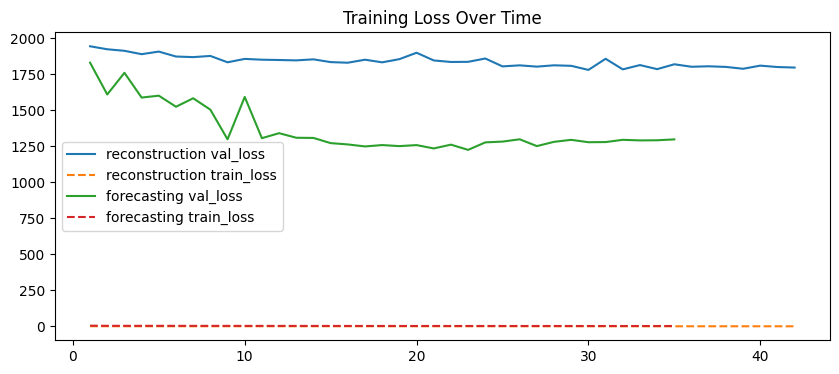

In [6]:
import matplotlib.pyplot as plt
history = pd.read_csv(MODEL_DIR / "training_history_all.csv")
display(history.tail())

plt.figure(figsize=(10,4))
for mode in history['model_name'].unique():
    subset = history[history['model_name'] == mode]
    plt.plot(subset['epoch'], subset['val_loss'], label=mode + " val_loss")
    plt.plot(subset['epoch'], subset['train_loss'], label=mode + " train_loss", linestyle='--')
plt.title('Training Loss Over Time')
plt.legend()
plt.show()

In [7]:
print("Threshold Configuration:")
display(read_json(MODEL_DIR / "threshold_config.json"))

Threshold Configuration:


{'default_mode': 'hybrid',
 'selected_threshold': 29057.083984375,
 'alpha': 0.6,
 'beta': 0.4,
 'modes': {'reconstruction': {'threshold': 22485.302734375,
   'artifact_path': 'reconstruction_model.pt',
   'best_val_loss': 1778.4847062321032,
   'val_score_mean': 1778.4847412109375,
   'val_score_std': 7542.97265625},
  'forecasting': {'threshold': 42337.16015625,
   'artifact_path': 'forecasting_model.pt',
   'best_val_loss': 1223.7973163115846,
   'val_score_mean': 1223.7972412109375,
   'val_score_std': 8174.19775390625},
  'hybrid': {'threshold': 29057.083984375,
   'val_score_mean': 1556.6097412109375,
   'val_score_std': 7185.92578125,
   'alpha': 0.6,
   'beta': 0.4}}}